In [1]:
# 1. 기본 설정: 라이브러리, 한글 폰트, 색상 팔레트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

COLOR_STAY = "#0ca30c"    # 잔존 (good)
COLOR_CHURN = "#d03b3b"   # 이탈 (critical)
CAT_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]  # 범주형 비교용

(970960, 2)
is_churn
0    0.910058
1    0.089942
Name: proportion, dtype: float64


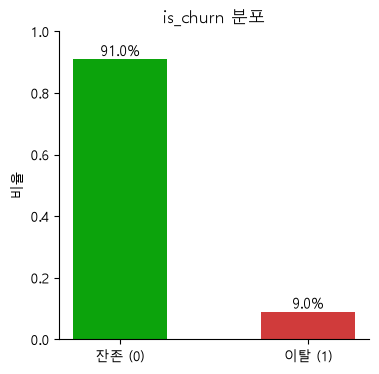

In [2]:
# 2. train_v2 로드: 예측 대상 고객 + 이탈 라벨(is_churn)
# -> 970,960명, 이탈 9.0% / 잔존 91.0% : 불균형 데이터
train = pd.read_csv("../data/train_v2.csv")
print(train.shape)
ratio = train["is_churn"].value_counts(normalize=True).sort_index()
print(ratio)

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["잔존 (0)", "이탈 (1)"], ratio.values, color=[COLOR_STAY, COLOR_CHURN], width=0.5)
for i, v in enumerate(ratio.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel("비율")
ax.set_title("is_churn 분포")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [3]:
# 3. members_v3 로드 후 train 대상 고객만 필터링 (전체 677만 명 -> 필요한 회원만)
# -> train 97만 명 중 86만 명만 members에 존재 -> 약 11만 명은 회원 정보 자체가 없음 (실무 데이터의 조인 결측)
members = pd.read_csv("../data/members_v3.csv")
print("members 전체:", members.shape)

target_users = set(train["msno"])
members = members[members["msno"].isin(target_users)]
print("train 대상으로 필터링:", members.shape)
print("train 대비 매칭률:", len(members) / len(train))
members.head()

members 전체: (6769473, 6)


train 대상으로 필터링: (860967, 6)
train 대비 매칭률: 0.8867172695064678


,msno,city,bd,gender,registered_via,registration_init_time
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
5,yLkV2gbZ4GLFwqTOXLVHz0VGrMYcgBGgKZ3kj9RiYu8=,4,30,male,9,20110916
9,I0yFvqMoNkM8ZNHb617e1RBzIS/YRKemHO7Wj13EtA0=,13,63,male,9,20110918
10,OoDwiKZM+ZGr9P3fRivavgOtglTEaNfWJO4KaJcTTts=,1,0,NaN,7,20110918
13,4De1jAxNRABoyRBDZ82U0yEmzYkqeOugRGVNIf92Xb8=,4,28,female,9,20110920


In [4]:
# 4. members 컬럼별 결측치/이상치 점검
# -> gender 결측 54.8% (실서비스에서 프로필 미입력 흔함)
# -> bd(나이)는 min=-3152, max=2016, 중앙값 0 : 명백한 이상치/미입력 placeholder -> 다음 셀에서 정제
print(members.isnull().sum())
print()
print("bd(나이) 기술통계:")
print(members["bd"].describe())

msno                           0
city                           0
bd                             0
gender                    472062
registered_via                 0
registration_init_time         0
dtype: int64

bd(나이) 기술통계:
count    860967.000000
mean         13.583854
std          20.064040
min       -3152.000000
25%           0.000000
50%           0.000000
75%          27.000000
max        2016.000000
Name: bd, dtype: float64


In [5]:
# 5. bd(나이) 정제: 상식적 범위(10~80세)만 유효값으로 인정, 나머지는 결측 처리
# -> 유효 나이 비율 44.9%(필터링된 members 기준) : 회원의 약 55%는 나이 정보 신뢰 불가
members["bd_clean"] = members["bd"].where(members["bd"].between(10, 80))
print("유효 나이 비율:", members["bd_clean"].notnull().mean())
members["bd_clean"].describe()

유효 나이 비율: 0.4487895587171169


count    386393.000000
mean         29.876853
std           8.797025
min          10.000000
25%          24.000000
50%          28.000000
75%          34.000000
max          80.000000
Name: bd_clean, dtype: float64

In [6]:
# 6. 범주형 회원 정보 분포 확인: city, gender, registered_via
# -> city는 21개 카테고리로 다양, registered_via는 5개 가입 경로
print("city 카테고리 수:", members["city"].nunique())
print()
print("gender 분포(결측 포함):")
print(members["gender"].value_counts(dropna=False))
print()
print("registered_via 분포:")
print(members["registered_via"].value_counts())

city 카테고리 수: 21

gender 분포(결측 포함):
gender
NaN       472062
male      204561
female    184344
Name: count, dtype: int64

registered_via 분포:
registered_via
7     462684
9     235689
3     106459
4      52744
13      3391
Name: count, dtype: int64


In [7]:
# 7. transactions 로드 (transactions.csv 1.7GB + transactions_v2.csv 115MB)
# -> 파일이 커서 train 대상 97만 명 거래만 청크 단위로 필터링 후 parquet으로 캐싱
# -> 최초 1회는 1~2분 소요, 이후에는 캐시 파일을 바로 읽어 수 초 내 완료
import os

CACHE_PATH = "../data/transactions_filtered.parquet"

if os.path.exists(CACHE_PATH):
    transactions = pd.read_parquet(CACHE_PATH)
else:
    chunks = []
    for fname in ["../data/transactions.csv", "../data/transactions_v2.csv"]:
        for chunk in pd.read_csv(fname, chunksize=2_000_000):
            filtered = chunk[chunk["msno"].isin(target_users)]
            if len(filtered):
                chunks.append(filtered)
    transactions = pd.concat(chunks, ignore_index=True)
    transactions.to_parquet(CACHE_PATH)

print(transactions.shape)
transactions.head()

(16255622, 9)


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
1,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0
2,KN7I82kjY0Tn76Ny95ncqBUVbO7b8AXrOPqZutKpxIM=,21,30,149,149,1,20150930,20151107,0
3,m5ptKif9BjdUghHXXomSezy5ohJiHm85PE13f/3kQaw=,39,30,149,149,1,20150930,20151128,0
4,LUPRfoE2r3WwVWhYO/TqQhjrL/qP6CO+/ORUlr7yNc0=,39,30,149,149,1,20150930,20151222,0


In [8]:
# 8. 고객별 거래 이력을 요약 피처로 집계
# -> tx_count: 총 결제 횟수 / total_paid: 총 결제금액 / cancel_count: 해지 신청 횟수
# -> last_auto_renew, last_plan_days: 가장 최근 거래 기준 자동갱신 여부/요금제 기간
# -> last_transaction_date: 다음 셀의 누수 점검에 사용
tx_agg = (
    transactions.sort_values("transaction_date")
    .groupby("msno")
    .agg(
        tx_count=("transaction_date", "count"),
        total_paid=("actual_amount_paid", "sum"),
        cancel_count=("is_cancel", "sum"),
        last_auto_renew=("is_auto_renew", "last"),
        last_plan_days=("payment_plan_days", "last"),
        last_transaction_date=("transaction_date", "last"),
    )
    .reset_index()
)
print(tx_agg.shape)
tx_agg.describe()

(970960, 7)


,tx_count,total_paid,cancel_count,last_auto_renew,last_plan_days,last_transaction_date
count,970960.000000,970960.000000,970960.000000,970960.000000,970960.000000,9.709600e+05
mean,16.741804,2301.645895,0.289709,0.882874,35.520837,2.017020e+07
std,8.736920,1310.155542,0.595502,0.321571,39.918572,1.079604e+03
min,1.000000,0.000000,0.000000,0.000000,0.000000,2.015010e+07
25%,9.000000,1188.000000,0.000000,1.000000,30.000000,2.017031e+07
50%,17.000000,2079.000000,0.000000,1.000000,30.000000,2.017032e+07
75%,24.000000,3427.000000,0.000000,1.000000,30.000000,2.017033e+07
max,244.000000,16800.000000,21.000000,1.000000,450.000000,2.017033e+07


In [9]:
# 9. train + members + 거래 집계 피처를 하나의 데이터프레임으로 병합
# -> members/거래 정보가 없는 고객은 결측으로 남음 (모델링 단계에서 결측 처리 필요)
df = train.merge(members, on="msno", how="left").merge(tx_agg, on="msno", how="left")
print(df.shape)
print(df.isnull().sum())
df.head()

(970960, 14)
msno                           0
is_churn                       0
city                      109993
bd                        109993
gender                    582055
registered_via            109993
registration_init_time    109993
bd_clean                  584567
tx_count                       0
total_paid                     0
cancel_count                   0
last_auto_renew                0
last_plan_days                 0
last_transaction_date          0
dtype: int64


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,bd_clean,tx_count,total_paid,cancel_count,last_auto_renew,last_plan_days,last_transaction_date
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,28.0,6,894,1,0,30,20170228
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,20.0,6,807,0,0,30,20170311
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,18.0,20,2982,0,0,90,20170314
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,NaN,7.0,20140109.0,NaN,29,4172,3,1,30,20160225
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0,35.0,32,3748,3,1,30,20170316


In [10]:
# 10. 거래 집계 피처의 데이터 누수 점검
# -> tx_agg는 transactions.csv + transactions_v2.csv 전체 기간(~2017-03-31)의 거래를 그대로 사용했는데,
#    train_v2에는 만료 시점이 다른 여러 고객군(1~3월)이 섞여 있음
# -> is_churn=0(잔존) 고객은 3월에도 결제가 이어져 마지막 거래월이 3월에 99.0% 몰려 있고,
#    is_churn=1(이탈) 고객은 만료 후 결제가 끊겨 마지막 거래월이 2월 이전으로 분산됨(3월 58.6%, 2월 26.7%)
# -> 즉 last_auto_renew/last_plan_days는 "이탈을 미리 예측"하는 게 아니라 "이미 이탈해서 결제가 끊긴 결과"를
#    거꾸로 반영하는 것 -> 은행 프로젝트의 Complain과 동일한 성격의 데이터 누수
# -> last_auto_renew 평균도 is_churn=0은 0.93, is_churn=1은 0.44로 크게 갈림 (역시 결과의 반영)
df["last_tx_month"] = df["last_transaction_date"] // 100
print(df.groupby("is_churn")["last_tx_month"].value_counts(normalize=True).groupby(level=0).head(3))
print()
print("last_auto_renew 평균 (is_churn별):")
print(df.groupby("is_churn")["last_auto_renew"].mean())

is_churn  last_tx_month
0         201703           0.990350
          201702           0.008621
          201701           0.000269
1         201703           0.586316
          201702           0.266690
          201602           0.031238
Name: proportion, dtype: float64

last_auto_renew 평균 (is_churn별):
is_churn
0    0.926185
1    0.444635
Name: last_auto_renew, dtype: float64


                     mean   count
last_auto_renew                  
0                0.426467  113725
1                0.045297  857235


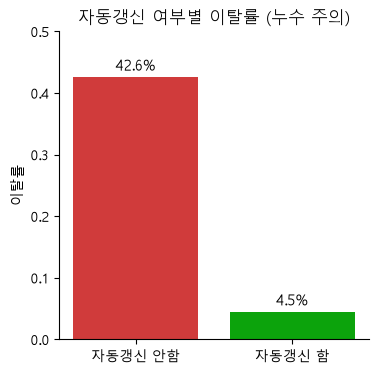

In [11]:
# 11. last_auto_renew 별 이탈률 (참고: 위 10번 셀에서 확인했듯 이 피처는 데이터 누수를 포함하고 있어
#     실제 모델링에는 그대로 쓸 수 없음 -> 02_modeling.ipynb에서 관측 시점 기준으로 다시 만들어야 함)
# -> 자동갱신 안 함(0): 42.6% 이탈 / 자동갱신 함(1): 4.5% 이탈 -> 거의 10배 차이 (수치 자체는 누수로 부풀려짐)
rate = df.groupby("last_auto_renew")["is_churn"].agg(["mean", "count"])
print(rate)

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["자동갱신 안함", "자동갱신 함"], rate["mean"], color=[COLOR_CHURN, COLOR_STAY])
for i, v in enumerate(rate["mean"]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=11)
ax.set_ylim(0, 0.5)
ax.set_ylabel("이탈률")
ax.set_title("자동갱신 여부별 이탈률 (누수 주의)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

                  mean   count
cancel_count                  
False         0.067316  745988
True          0.164967  224972


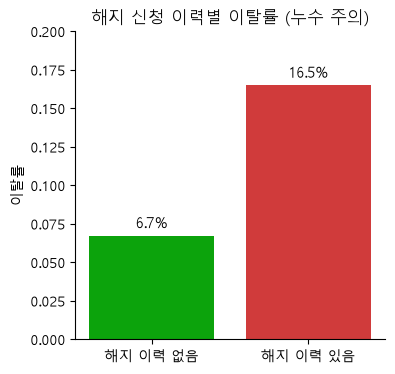

In [12]:
# 12. 해지 신청 이력(cancel_count) 유무에 따른 이탈률 (이 피처 역시 전체 기간 집계라 10번 셀과 같은 누수 소지 있음)
# -> 해지 이력 있음: 16.5% 이탈 / 없음: 6.7% 이탈 -> 과거 해지 시도가 재이탈 위험 신호일 수 있으나, 수치 해석은 보수적으로
has_cancel = df["cancel_count"] > 0
rate = df.groupby(has_cancel)["is_churn"].agg(["mean", "count"])
print(rate)

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["해지 이력 없음", "해지 이력 있음"], rate["mean"], color=[COLOR_STAY, COLOR_CHURN])
for i, v in enumerate(rate["mean"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)
ax.set_ylim(0, 0.2)
ax.set_ylabel("이탈률")
ax.set_title("해지 신청 이력별 이탈률 (누수 주의)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

            mean   count
gender                  
female  0.129866  184344
male    0.129037  204561
NaN     0.063558  582055


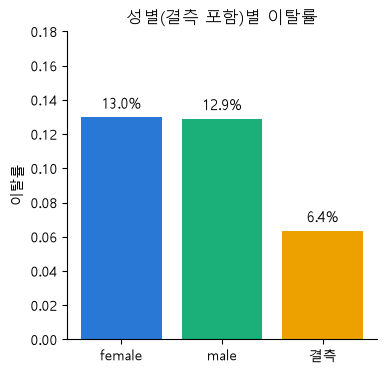

In [13]:
# 13. gender 별 이탈률 (결측 포함) - members 정적 정보라 위 누수 이슈와 무관, 신뢰 가능
# -> male(12.9%)과 female(13.0%)은 거의 차이 없음
# -> gender 결측 그룹은 이탈률이 오히려 6.4%로 더 낮음 -> 결측 자체가 하나의 신호(저관여/다른 유입경로 추정)일 수 있음
rate = df.groupby("gender", dropna=False)["is_churn"].agg(["mean", "count"])
print(rate)

labels = ["female", "male", "결측"]
values = [rate.loc["female", "mean"], rate.loc["male", "mean"], rate.loc[np.nan, "mean"]]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(labels, values, color=CAT_COLORS[:3])
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)
ax.set_ylim(0, 0.18)
ax.set_ylabel("이탈률")
ax.set_title("성별(결측 포함)별 이탈률")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

                    mean   count
registered_via                  
4.0             0.231022   52744
3.0             0.172254  106459
9.0             0.126832  235689
13.0            0.098791    3391
7.0             0.044732  462684


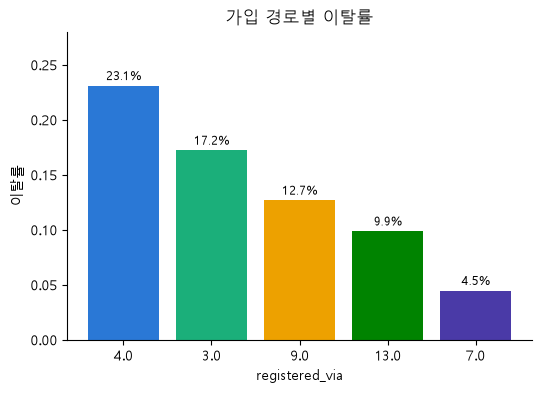

In [14]:
# 14. registered_via(가입 경로)별 이탈률 - members 정적 정보라 신뢰 가능
# -> 경로 7: 4.5%(최저) / 경로 4: 23.1%(최고) -> 가입 경로에 따라 5배 이상 차이
# -> 가입 경로가 다르면 유입 채널/프로모션 성격이 달라 이탈 성향도 크게 다른 것으로 추정
rate = df.groupby("registered_via")["is_churn"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print(rate)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rate.index.astype(str), rate["mean"], color=CAT_COLORS[: len(rate)])
for i, v in enumerate(rate["mean"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 0.28)
ax.set_xlabel("registered_via")
ax.set_ylabel("이탈률")
ax.set_title("가입 경로별 이탈률")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

              mean   count
bd_clean                  
(10, 20]  0.245221   41428
(20, 30]  0.130401  195420
(30, 40]  0.107729  104707
(40, 50]  0.101841   32315
(50, 60]  0.082175   10429
(60, 80]  0.105137    2083


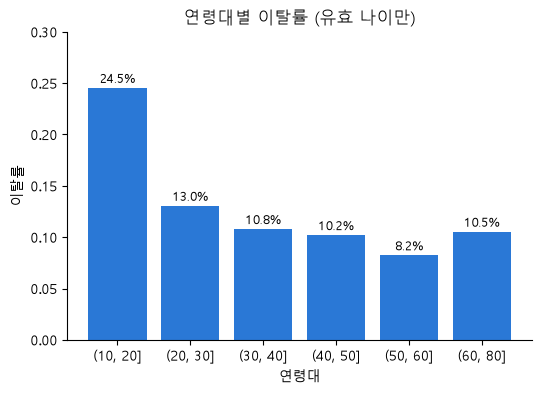

In [15]:
# 15. 정제된 연령대(bd_clean)별 이탈률 (유효 나이 데이터를 가진 39.8%만 대상, train 전체 기준) - members 정적 정보라 신뢰 가능
# -> 10대(24.5%)에서 가장 높고 연령이 올라갈수록 감소, 50대(8.2%)에서 최저 후 60대 이상 소폭 반등
bins = [10, 20, 30, 40, 50, 60, 80]
age_group = pd.cut(df["bd_clean"], bins=bins)
rate = df.groupby(age_group, observed=True)["is_churn"].agg(["mean", "count"])
print(rate)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rate.index.astype(str), rate["mean"], color=CAT_COLORS[0])
for i, v in enumerate(rate["mean"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 0.3)
ax.set_xlabel("연령대")
ax.set_ylabel("이탈률")
ax.set_title("연령대별 이탈률 (유효 나이만)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [16]:
# 16. user_logs.csv 구조 확인 (일별 청취 활동 로그)
# -> transactions.csv와 달리 user_logs.csv는 약 30.5GB(+ user_logs_v2.csv 1.4GB)로 훨씬 커서,
#    "전체를 청크로 필터링해 메모리에 캐싱"하는 방식은 필터링된 결과만도 수천만 행이 되어 메모리 부족(MemoryError)이 발생함
# -> 따라서 EDA 단계에서는 구조 파악용으로 일부만 샘플링해서 확인하고,
#    실제 관측 시점 기준 피처 집계는 02_preprocessing.ipynb에서 청크 단위로 즉시 집계(스트리밍 방식)해서 처리한다
sample_logs = pd.read_csv("../data/user_logs.csv", nrows=1_000_000)
print(sample_logs.shape)
print("날짜 범위(샘플 기준):", sample_logs["date"].min(), "~", sample_logs["date"].max())
sample_logs.head()

(1000000, 9)
날짜 범위(샘플 기준): 20150101 ~ 20170228


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34=,20150513,0,0,0,0,1,1,280.335
1,rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34=,20150709,9,1,0,0,7,11,1658.948
2,yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=,20150105,3,3,0,0,68,36,17364.956
3,yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=,20150306,1,0,1,1,97,27,24667.317
4,yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8=,20150501,3,0,0,0,38,38,9649.029


In [17]:
# 17. user_logs 활용 시 주의사항 정리
# -> transactions와 동일하게 2015-01 ~ 2017-03-31까지 전체 기간의 로그이므로,
#    고객의 마지막(=이탈 여부를 결정짓는) 거래 시점 이후의 청취 기록을 그대로 쓰면
#    "이미 이탈한 뒤/이탈 직전의 결과"가 섞여 들어가는 누수가 생길 수 있음
# -> 컬럼 구성: num_25/50/75/985/100(재생 진행률 구간별 곡 수), num_unq(고유 재생곡 수), total_secs(총 재생시간)
#    -> num_100에 가까울수록 완청, num_25에 가까울수록 스킵에 가까움
# -> 02_preprocessing.ipynb에서는 각 고객의 마지막 거래일 이전 로그만, 청크 단위로 즉시 집계해서 사용한다
print("컬럼:", list(sample_logs.columns))

컬럼: ['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']


In [18]:
# 18. EDA 결론 요약
# - 대상 규모: train 970,960명 / members 필터링 후 86만 명 매칭 / transactions 필터링 후 1,625만 건
# - 타겟 불균형: 이탈 9.0% (은행 프로젝트보다 훨씬 불균형) -> recall/f1/roc-auc 중심 평가 필요
# - 결측치: members 조인 실패 11만 명(11.3%), gender 결측 54.8%, bd(나이) 유효값 44.9%(members 기준)/39.8%(train 전체 기준)
#
# - last_auto_renew, cancel_count 등 거래 집계 피처는 데이터 누수 포함 (10번 셀 참고)
#   -> 전체 기간(~2017-03-31) 거래를 그대로 집계해서, "이탈 여부를 예측"하는 게 아니라
#      "이미 이탈해서 결제가 끊긴 결과"를 반영함 (은행 프로젝트의 Complain과 동일한 성격)
#   -> 02_preprocessing.ipynb에서는 각 고객의 관측 시점(마지막 거래일 이전) 기준으로 피처를 다시 만들어야 함
#
# - 신뢰 가능한 신호 (members 정적 정보, 누수 없음):
#   * registered_via(가입 경로, 최대 5배 차이), bd_clean(연령대, 10대에서 최고 24.5%)
#   * gender는 차이 거의 없음, gender 결측 그룹은 오히려 이탈률 낮음(반직관적)
#
# - user_logs(청취 활동 로그, 16~17번 셀 참고)는 30GB가 넘어 transactions처럼 통째로 필터링/캐싱하면
#   메모리 부족이 발생함 -> 02_preprocessing.ipynb에서 각 고객의 마지막 거래일 이전 로그만 청크 단위로
#   즉시 집계(스트리밍 방식)해서 청취 활동 피처(활동 일수, 일평균 청취 시간/곡수, 완청 비율 등)를 만들어
#   기존 피처에 추가하면 성능 개선을 기대할 수 있음
#
# - 다음 단계: 관측 시점 기준 거래/청취 피처 재설계 + 결측치 처리 + 인코딩 후 모델 학습 (02_preprocessing.ipynb)
print("EDA 완료. 다음 단계: 전처리 및 모델 개발 (02_preprocessing.ipynb)")

EDA 완료. 다음 단계: 전처리 및 모델 개발 (02_preprocessing.ipynb)


In [ ]:
# 19. data/ 폴더 CSV 컬럼 설명 정리
#
# [train_v2.csv] 예측 대상 회원 + 정답 라벨
#   msno                    : 회원 고유 ID (익명화된 해시값)
#   is_churn                : 이탈 여부 (1=이탈, 0=잔존)
#                             -> 구독 만료 후 30일 이내 미갱신 시 이탈로 정의 (KKBox 공식 기준)
#
# [members_v3.csv] 회원 인구통계 정보 (가입 시점의 정적 정보 - 누수 없음)
#   msno                    : 회원 고유 ID
#   city                    : 거주 도시 (코드화된 범주, 21개)
#   bd                      : 나이(age) - KKBox 공식 정의도 "age"이며, 자체 입력값이라 이상치/결측 placeholder 많음
#                             (음수, 수천 단위 등 명백한 오류값 다수 -> bd_clean으로 정제해서 사용)
#   gender                  : 성별 (male/female, 결측 54.8%)
#   registered_via          : 가입 경로 (코드화된 범주, 5개: 3/4/7/9/13)
#   registration_init_time  : 최초 가입일 (YYYYMMDD)
#
# [transactions.csv, transactions_v2.csv] 결제/구독 거래 이력 (시점에 따라 누수 위험 있음, 10번 셀 참고)
#   -> transactions.csv: ~2017-02-28까지 전체 이력 / transactions_v2.csv: 2017-03 증분분
#   -> 두 파일을 합쳐야 온전한 거래 이력이 됨 (7번 셀에서 병합 처리)
#   msno                    : 회원 고유 ID
#   payment_method_id       : 결제 수단 코드
#   payment_plan_days       : 요금제 기간(일)
#   plan_list_price         : 요금제 정가
#   actual_amount_paid      : 실제 결제 금액
#   is_auto_renew           : 자동갱신 설정 여부 (1=자동갱신) -> 마지막 거래 기준으로 집계 시 누수 위험 있음(10번 셀)
#   transaction_date        : 거래(결제) 발생일 (YYYYMMDD)
#   membership_expire_date  : 해당 거래 기준 구독 만료일 (YYYYMMDD)
#   is_cancel               : 해당 거래가 해지 신청인지 여부 (1=해지 신청)
#                             -> 해지 신청 ≠ 실제 이탈 (해지 후 재가입하거나 만료 전 취소하는 경우도 있음)
#
# [user_logs.csv, user_logs_v2.csv] 일별 청취 활동 로그 (거래와 동일하게 시점에 따라 누수 위험 있음, 17번 셀 참고)
#   -> user_logs.csv: ~2017-02-28까지 전체 이력 (약 30.5GB) / user_logs_v2.csv: 2017-03 증분분 (약 1.4GB)
#   -> 용량이 너무 커서 이 노트북에서는 구조만 샘플링 확인(16번 셀)하고, 실제 두 파일 병합·집계는
#      02_preprocessing.ipynb에서 청크 단위 스트리밍 방식으로 처리한다
#   msno                    : 회원 고유 ID
#   date                    : 청취가 발생한 날짜 (YYYYMMDD)
#   num_25/50/75/985/100    : 각각 곡 길이의 25%/50%/75%/98.5%/100% 지점까지 재생한 곡 수
#                             (num_25에 가까울수록 '스킵'에 가깝고, num_100에 가까울수록 '완청'에 가까움)
#   num_unq                 : 그 날 재생한 고유(중복 제외) 곡 수
#   total_secs              : 그 날 총 재생 시간(초)